In [16]:
import pandas as pd
import ast
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply({lambda x: ast.literal_eval(x) if pd.notna(x) else(x)})

In [17]:
df = df[df['job_title_short'] == 'Data Analyst']

In [18]:
df_exploded = df.explode('job_skills')

skill_state = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'size'),
    median_salary =('salary_year_avg', 'median')
)

In [19]:
top10=skill_state.sort_values(by='skill_count', ascending=False).head(10)

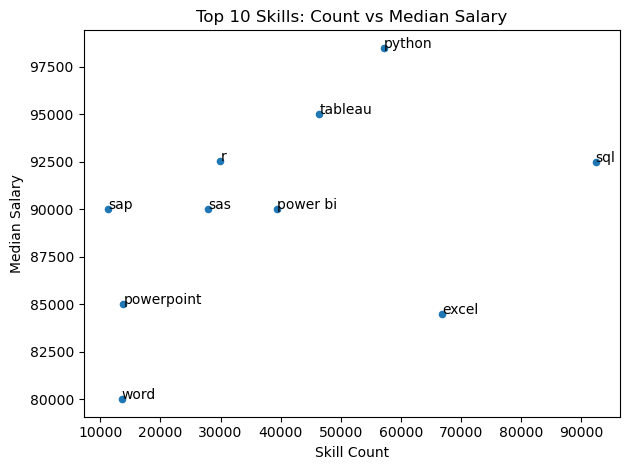

In [26]:
top10.plot(kind='scatter', x='skill_count', y='median_salary')
plt.title('Top 10 Skills: Count vs Median Salary')
plt.xlabel('Skill Count')
plt.ylabel('Median Salary')
plt.tight_layout()


for i, txt in enumerate(top10.index):
    plt.text(top10['skill_count'].iloc[i], top10['median_salary'].iloc[i],txt)
    
plt.show()